# Post-Quantum KEM Performance Analysis

This Jupyter Notebook focuses on the performance evaluation of various Post-Quantum Cryptography (**PQC**) Key Encapsulation Mechanisms (**KEMs**), specifically those selected during the NIST PQC standardization process. It precisely measures **key generation times** and the **sizes of public and private keys** across different [**NIST security levels**](https://csrc.nist.rip/groups/ST/post-quantum-crypto/evaluation-criteria.html). The collected data, including key sizes and security levels which can also be referenced from the [**liboqs**](https://openquantumsafe.org/liboqs/algorithms) documentation, are clearly presented in tables and charts. The overarching goal is to assess the practical applicability of these forward-looking PQC algorithms based on their performance. While AES is included for comparison because its security levels correspond to the NIST PQC levels and it is also considered secure against quantum attacks, it's crucial to note that as a symmetric encryption algorithm, its fundamental operation differs significantly from asymmetric KEMs, making a direct comparison regarding key generation and size challenging. ![Key Encapsulation Mechanisms](https://examroom.ai/blog/wp-content/uploads/2024/04/low-res-open_2-1-1.png)

## Table of Contents
- [Requirements](#requirements)
- [Code](#code)
- [Output](#output)
    - [Level 1](#l1)
    - [Level 2](#l2)
    - [Level 3](#l3)
- [Conclusion](#conclusion)

## Requirements <a id="requirements"></a>

In [1]:
import sys
!"{sys.executable}" -m pip install -q -r requirements.txt

In [2]:
# Requirements 
import oqs
import timeit
import pandas as pd
from Crypto.Cipher import AES
import os
import matplotlib.pyplot as plt
import seaborn as sns

/home/pqc/venv/lib/python3.13/site-packages/oqs/__init__.py:1: UserWarning: liboqs version (major, minor) 0.13.1-dev differs from liboqs-python version 0.12.0
  from oqs.oqs import (


In [3]:
# Panda options
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Definitions
encryption_L1 = ["ML-KEM-512","HQC-128", "AES-128"]
encryption_L3 = ["ML-KEM-768", "HQC-192", "AES-192"]
encryption_L5 = ["ML-KEM-1024", "HQC-256", "AES-256"]

test_runs = 10000

## Code <a id="code"></a>

In [4]:
# Functions
def generate_keys(algorithm, security_level):
    if algorithm.startswith("AES"):
        key_bytes = int(algorithm.split('-')[1]) // 8
        key = os.urandom(key_bytes)
        return { 'Algorithm': algorithm, 'Security Level': security_level,
            'Public Key (hex)': "Not available", 'Public Key length': 0,
            'Secret Key (hex)': key.hex(), 'Secret Key length': len(key)}, None
    else:
        receiver = oqs.KeyEncapsulation(algorithm)
        public_key = receiver.generate_keypair()
        secret_key = receiver.export_secret_key()
        return { 'Algorithm': algorithm, 'Security Level': security_level,
            'Public Key (hex)': public_key.hex(), 'Public Key length': len(public_key),
            'Secret Key (hex)': secret_key.hex(), 'Secret Key length': len(secret_key)}, receiver

def encryption(algorithm, security_level, public_key_client):
    with oqs.KeyEncapsulation(algorithm) as sender:
        ciphertext, shared_secret_sender = sender.encap_secret(public_key_client)
        return { 'Algorithm': algorithm, 'Security Level': security_level,
            'Ciphertext (hex)': ciphertext.hex(), 'Ciphertext length': len(ciphertext),
            'Shared Secret Sender' : shared_secret_sender.hex(), 'Shared Secret Sender length' : len(shared_secret_sender)}

def decryption(algorithm, security_level, receiver_instance, ciphertext):
    shared_secret_receiver = receiver_instance.decap_secret(ciphertext)
    return { 'Algorithm': algorithm, 'Security Level': security_level,
        'Shared Secret Receiver' : shared_secret_receiver.hex(), 'Shared Secret Receiver length' : len(shared_secret_receiver)}


def times_to_df(algorithm: str, execution_times: list, security_level: str, operation_type: str) -> pd.DataFrame:
    avg_time = sum(execution_times) / len(execution_times)
    min_time = min(execution_times)
    max_time = max(execution_times)
    data = {
        'Algorithm': [algorithm],
        'Security Level': [security_level],
        'Operation': [operation_type],
        'Min_Time (s)': [min_time], 
        'Average_Time (s)': [avg_time], 
        'Max_Time (s)': [max_time] 
    }
    return pd.DataFrame(data)

def measure_execution_times(func, num_runs, *func_args):
    times = timeit.repeat(lambda: func(*func_args), number=1, repeat=num_runs)
    return times


def process_encryption_level(algorithms_list: list, runs: int, level_name: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    keys_data_list = []
    key_times_list = []
    encryption_data_list = []
    encryption_times_list = []
    decryption_data_list = []
    decryption_times_list = []

    for alg in algorithms_list:
        keys_info, receiver_instance = generate_keys(alg, level_name)
        keys_data_list.append(keys_info)

        times_keys = measure_execution_times(generate_keys, runs, alg, level_name)
        time_df_keys = times_to_df(alg, times_keys, level_name, "Key Generation")
        key_times_list.append(time_df_keys)

        if not alg.startswith("AES"):
            public_key_client = bytes.fromhex(keys_info['Public Key (hex)'])
            
            encryption_data = encryption(alg, level_name, public_key_client)
            encryption_data_list.append(encryption_data)

            times_encryption = measure_execution_times(encryption, runs, alg, level_name, public_key_client)
            time_df_encryption = times_to_df(alg, times_encryption, level_name, "Encryption")
            encryption_times_list.append(time_df_encryption)

            ciphertext_to_decap = encryption_data['Ciphertext (hex)']
            ciphertext_bytes = bytes.fromhex(ciphertext_to_decap)

            decryption_data = decryption(alg, level_name, receiver_instance, ciphertext_bytes)
            decryption_data_list.append(decryption_data)

            shared_secret_sender = encryption_data['Shared Secret Sender']
            shared_secret_receiver = decryption_data['Shared Secret Receiver']
            
            if shared_secret_sender == shared_secret_receiver:
                print(f"Shared Secret for {alg} ({level_name}) matches: True")
            else:
                print(f"Shared Secret for {alg} ({level_name}) matches: False") 

            times_decryption = measure_execution_times(decryption, runs, alg, level_name, receiver_instance, ciphertext_bytes)
            time_df_decryption = times_to_df(alg, times_decryption, level_name, "Decryption")
            decryption_times_list.append(time_df_decryption)
            
            if receiver_instance:
                receiver_instance.free()


    df_keys = pd.DataFrame(keys_data_list)
    df_time_keys = pd.concat(key_times_list, ignore_index=True)
    df_encryption = pd.DataFrame(encryption_data_list)
    df_time_encryption = pd.concat(encryption_times_list, ignore_index=True)
    df_decryption = pd.DataFrame(decryption_data_list)
    df_time_decryption = pd.concat(decryption_times_list, ignore_index=True)

    return df_keys, df_time_keys, df_encryption, df_time_encryption, df_decryption, df_time_decryption

In [5]:
#show Results

def display_results(level_name: str, df: pd.DataFrame, description: str):
    print(f"\n--- {description} ({level_name}) ---") 
    print(df)

def plot_key_length_comparison(df_keys_all: pd.DataFrame):
    print("\n--- Plot: Key Lengths ---")

    df_keys_all_melted = df_keys_all.melt(
        id_vars=['Algorithm', 'Security Level'],
        value_vars=['Public Key length', 'Secret Key length'],
        var_name='Key Type',
        value_name='Length (Bytes)'
    )

    df_keys_all_melted_filtered = df_keys_all_melted[df_keys_all_melted['Length (Bytes)'] > 0].copy()

    level_order = ["L1", "L3", "L5", "Unknown"]

    df_keys_all_melted_filtered.loc[:, 'Security Level'] = pd.Categorical(
        df_keys_all_melted_filtered['Security Level'], categories=level_order, ordered=True
    )

    df_keys_all_melted_filtered = df_keys_all_melted_filtered.sort_values(
        ['Security Level', 'Algorithm']
    )

    plt.figure(figsize=(15, 8))
    sns.barplot(
        data=df_keys_all_melted_filtered,
        x='Algorithm',
        y='Length (Bytes)',
        hue='Key Type'
    )
    plt.title('Key Lengths in Bytes per Algorithm') # Translated title
    plt.xlabel('Algorithm') # Translated label
    plt.ylabel('Length (Bytes)') # Translated label
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Key Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_timing_comparison(df_time_all: pd.DataFrame, runs: int, title_suffix: str, level: str): 
    print(f"\n--- Plot: {title_suffix} Times ---") 

    df_time_all_melted = df_time_all.melt(
        id_vars=['Algorithm', 'Security Level'],
        value_vars=['Min_Time (s)', 'Average_Time (s)', 'Max_Time (s)'],
        var_name='Time Metric',
        value_name='Time (s)' 
    )

    level_order = ["L1", "L3", "L5", "Unknown"]
    df_time_all_melted.loc[:, 'Security Level'] = pd.Categorical(
        df_time_all_melted['Security Level'], categories=level_order, ordered=True
    )
    df_time_all_melted = df_time_all_melted.sort_values(
        ['Security Level', 'Algorithm']
    )

    plt.figure(figsize=(15, 8))
    sns.barplot(
        data=df_time_all_melted,
        x='Algorithm',
        y='Time (s)', 
        hue='Time Metric', 
    )
    plt.title(f'{title_suffix} Times per Algorithm (L{level}) (Min, Average, Max over {runs} Runs)') 
    plt.xlabel('Algorithm') 
    plt.ylabel('Time (s) (Log Scale)') 
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Time Metric', bbox_to_anchor=(1.05, 1), loc='upper left') 
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.yscale('log')
    plt.tight_layout()
    plt.show()

## Output <a id="ouput"></a>

### Level 1 <a id="l1"></a>

In [6]:
print("\nLevel 1...")
df_keys_L1, df_time_keys_L1, df_encryption_L1,  df_time_encryption_L1, df_decryption_L1, df_time_decryption_L1 = process_encryption_level(encryption_L1, test_runs, "L1")


Level 1...
Shared Secret for ML-KEM-512 (L1) matches: True
Shared Secret for HQC-128 (L1) matches: True


In [7]:
display_results("L1", df_keys_L1, "Generated Keys")
display_results("L1", df_time_keys_L1, "Average Key Generation Times")


--- Generated Keys (L1) ---
    Algorithm Security Level  \
0  ML-KEM-512             L1   
1     HQC-128             L1   
2     AES-128             L1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [8]:
display_results("L1", df_encryption_L1, "Encryption Data")
display_results("L1", df_time_encryption_L1, "Average Encryption Times")


--- Encryption Data (L1) ---
    Algorithm Security Level  \
0  ML-KEM-512             L1   
1     HQC-128             L1   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [9]:
display_results("L1", df_decryption_L1, "Decryption Data")
display_results("L1", df_time_decryption_L1, "Average Decryption Times")


--- Decryption Data (L1) ---
    Algorithm Security Level  \
0  ML-KEM-512             L1   
1     HQC-128             L1   

                                                                                                             Shared Secret Receiver  \
0                                                                  6f18dba11f7b617e0f2ac7697c9fc789140b251b7ecb4008610119813159686c   
1  9c9c14292eae03a7d1e2908e5b0188a6fd3f9ee8452e2ff589dcf7e2090e6ab66bdec3cf0776474a535ded0802710fb4fcd85cb306f85acc5984f8e066f317c9   

   Shared Secret Receiver length  
0                             32  
1                             64  

--- Average Decryption Times (L1) ---
    Algorithm Security Level   Operation  Min_Time (s)  Average_Time (s)  \
0  ML-KEM-512             L1  Decryption      0.000028          0.000037   
1     HQC-128             L1  Decryption      0.004144          0.006139   

   Max_Time (s)  
0      0.001179  
1      0.084240  



--- Plot: Key Lengths ---


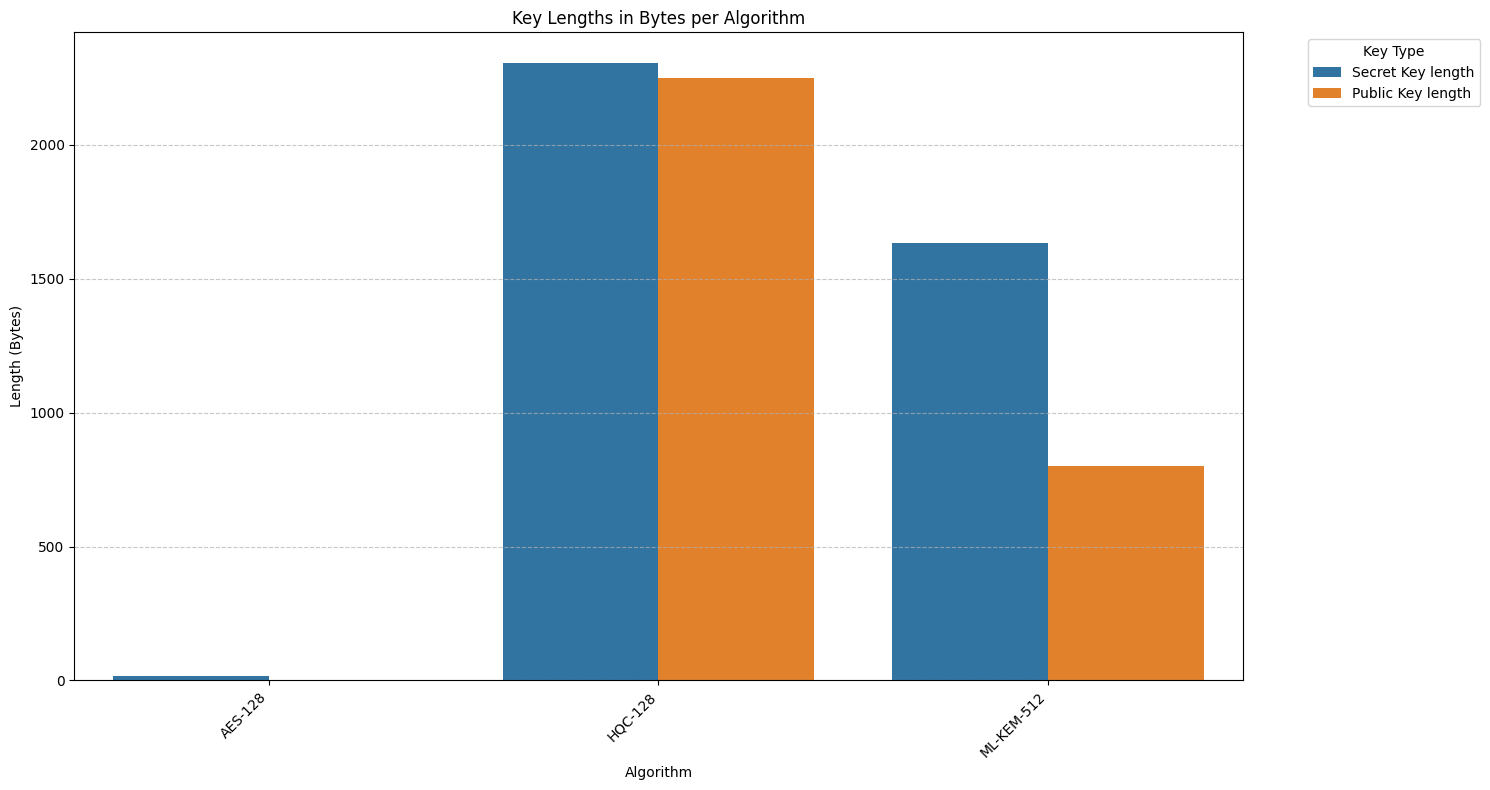

In [10]:
plot_key_length_comparison(df_keys_L1)


--- Plot: Key Generation Times ---


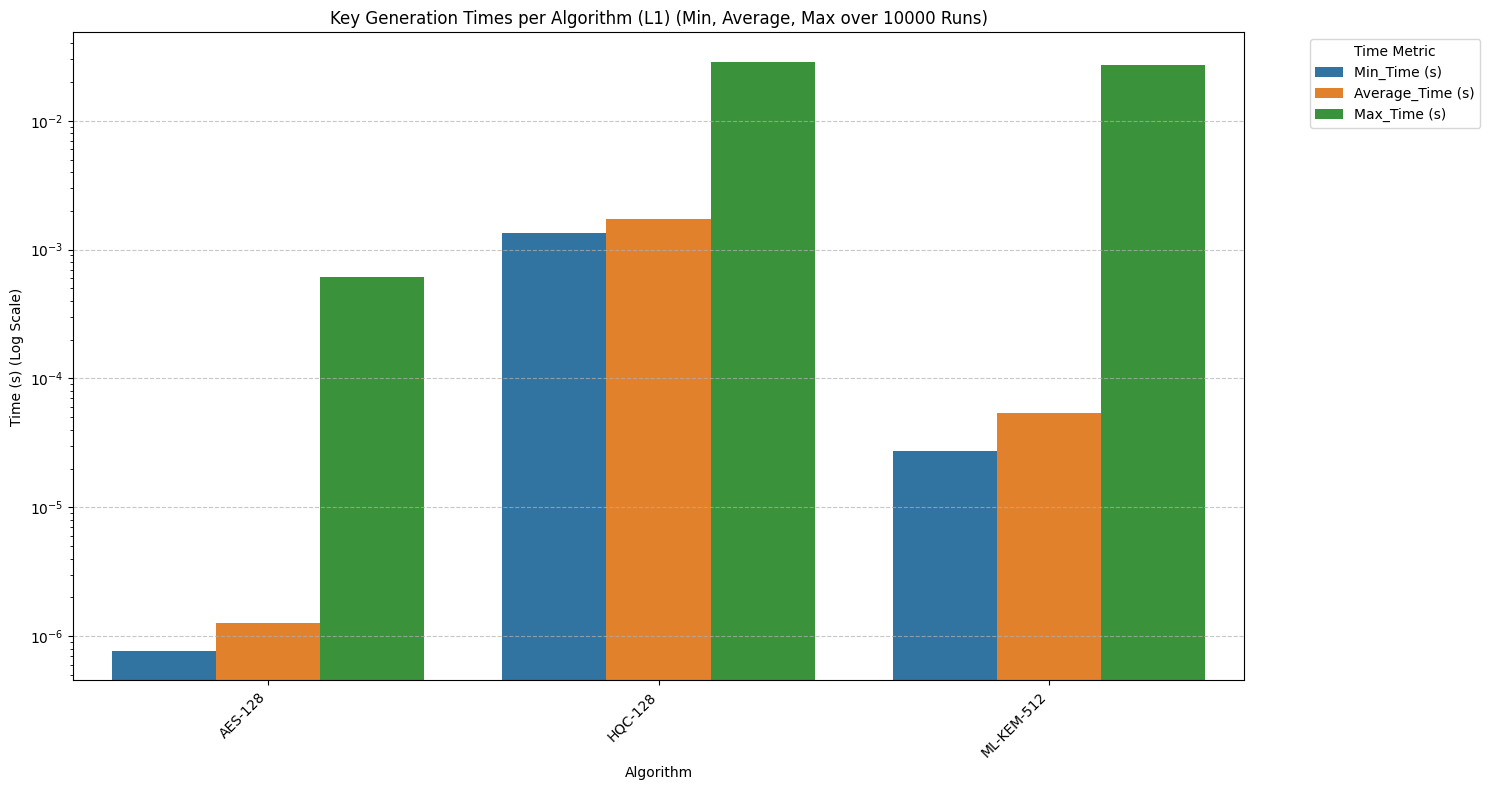

In [11]:
plot_timing_comparison(df_time_keys_L1, test_runs, "Key Generation", 1)


--- Plot: Encryption Times ---


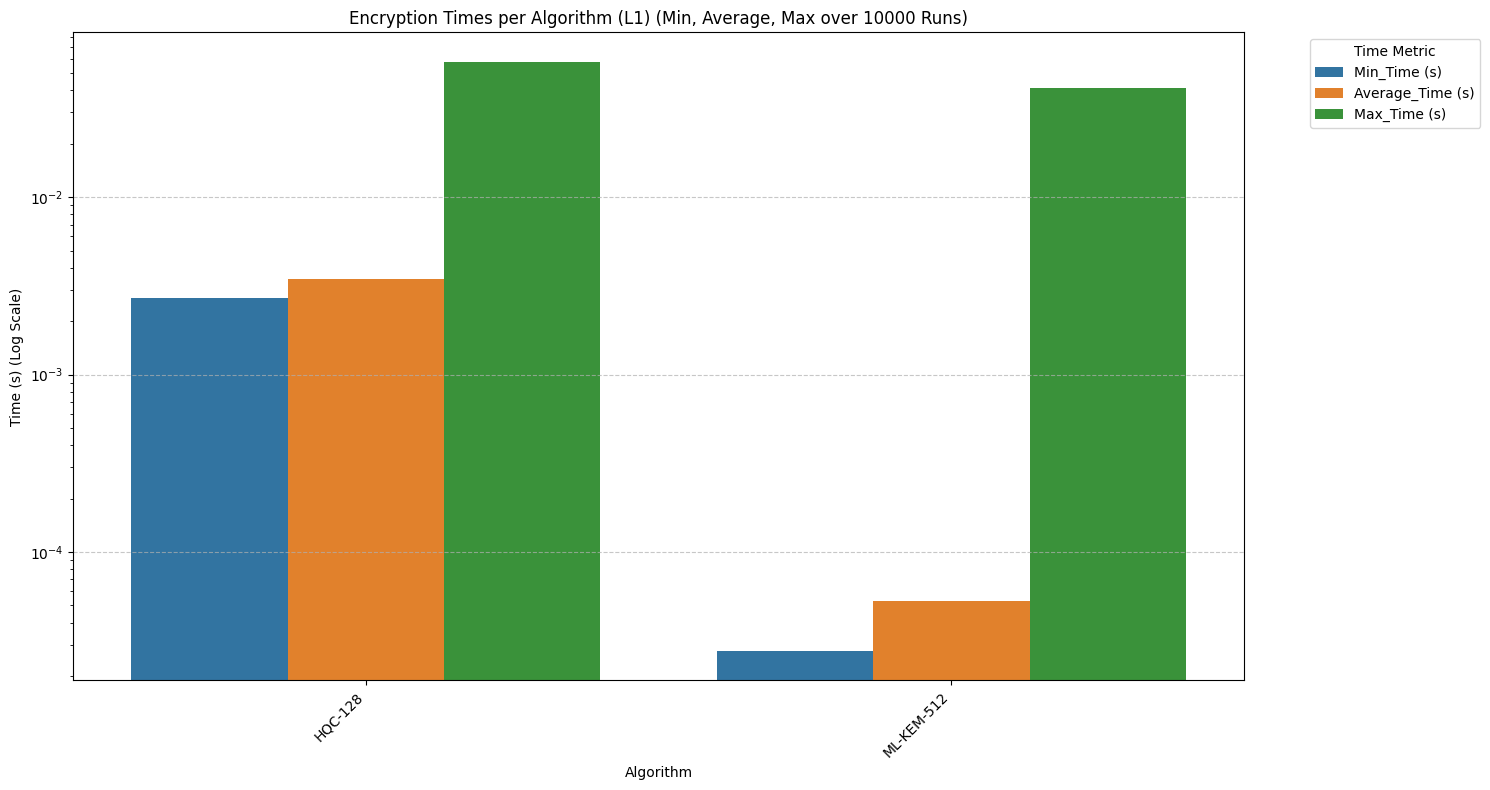

In [12]:
plot_timing_comparison(df_time_encryption_L1, test_runs, "Encryption", 1)


--- Plot: Decryption Times ---


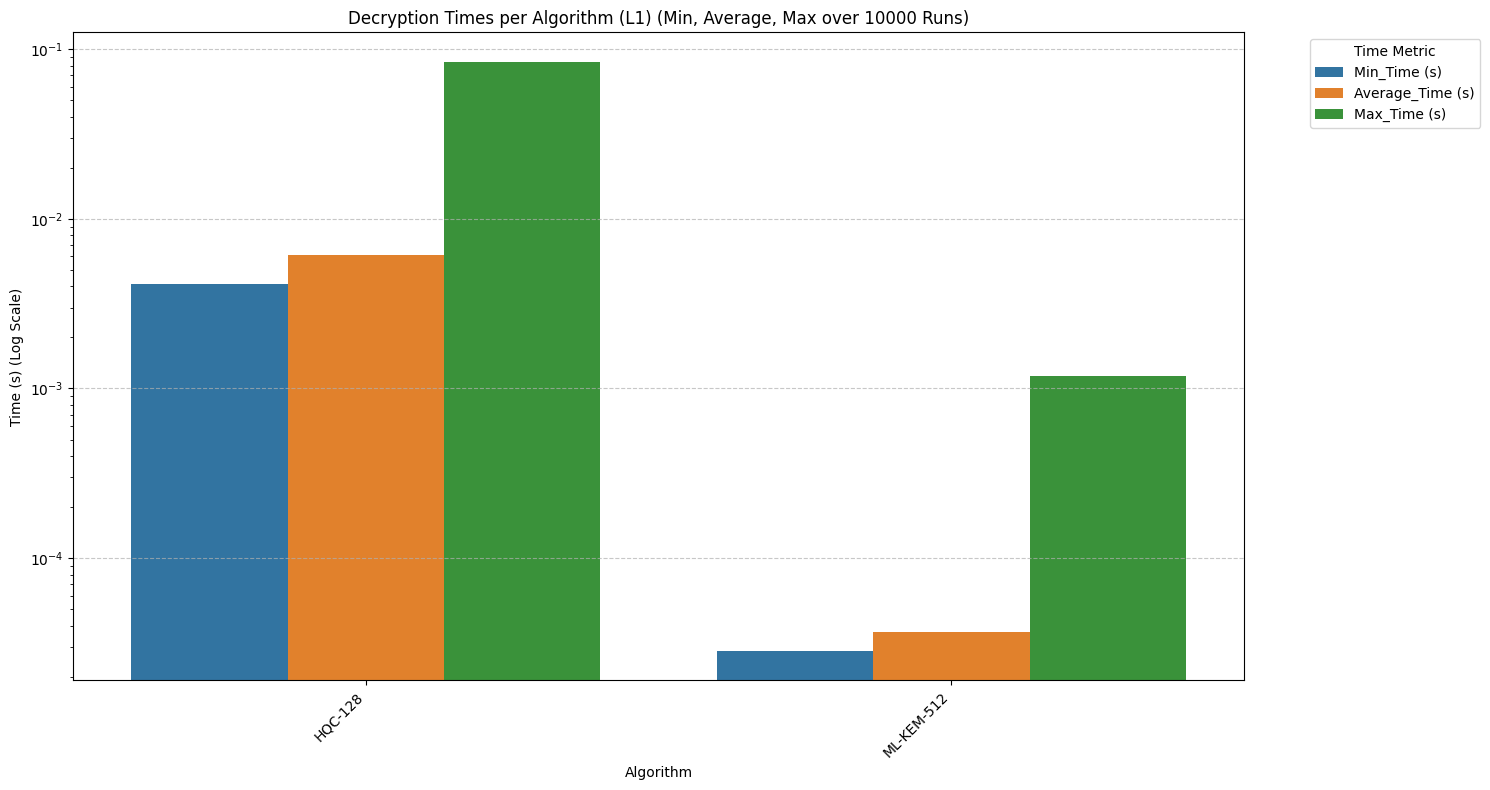

In [13]:
plot_timing_comparison(df_time_decryption_L1, test_runs, "Decryption", 1)

### Level 3 <a id="l3"></a>

In [14]:
print("\nLevel 3...")
df_keys_L3, df_time_keys_L3, df_encryption_L3, df_time_encryption_L3, df_decryption_L3, df_time_decryption_L3 = process_encryption_level(encryption_L3, test_runs, "L3")


Level 3...
Shared Secret for ML-KEM-768 (L3) matches: True
Shared Secret for HQC-192 (L3) matches: True


In [15]:
display_results("L3", df_keys_L3, "Generated Keys")
display_results("L3", df_time_keys_L3, "Average Key Generation Times")


--- Generated Keys (L3) ---
    Algorithm Security Level  \
0  ML-KEM-768             L3   
1     HQC-192             L3   
2     AES-192             L3   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          

In [16]:
display_results("L3", df_encryption_L3, "Encryption Data")
display_results("L3", df_time_encryption_L3, "Average Encryption Times")


--- Encryption Data (L3) ---
    Algorithm Security Level  \
0  ML-KEM-768             L3   
1     HQC-192             L3   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [17]:
display_results("L3", df_decryption_L3, "Decryption Data")
display_results("L3", df_time_decryption_L3, "Average Decryption Times")


--- Decryption Data (L3) ---
    Algorithm Security Level  \
0  ML-KEM-768             L3   
1     HQC-192             L3   

                                                                                                             Shared Secret Receiver  \
0                                                                  afab6bd274313767f8f0e80f754dc1ec659c3994561ded463cc41ff2d079e81d   
1  9a34b8f3bedf8473c12876742c0db384547be634df090d1976d3ef00cfd99b1692040ed033685722d70b359a82b627f8e62ca7be302b2831ac790b87580d2c15   

   Shared Secret Receiver length  
0                             32  
1                             64  

--- Average Decryption Times (L3) ---
    Algorithm Security Level   Operation  Min_Time (s)  Average_Time (s)  \
0  ML-KEM-768             L3  Decryption      0.000038          0.000076   
1     HQC-192             L3  Decryption      0.012610          0.016591   

   Max_Time (s)  
0      0.010701  
1      0.181860  



--- Plot: Key Lengths ---


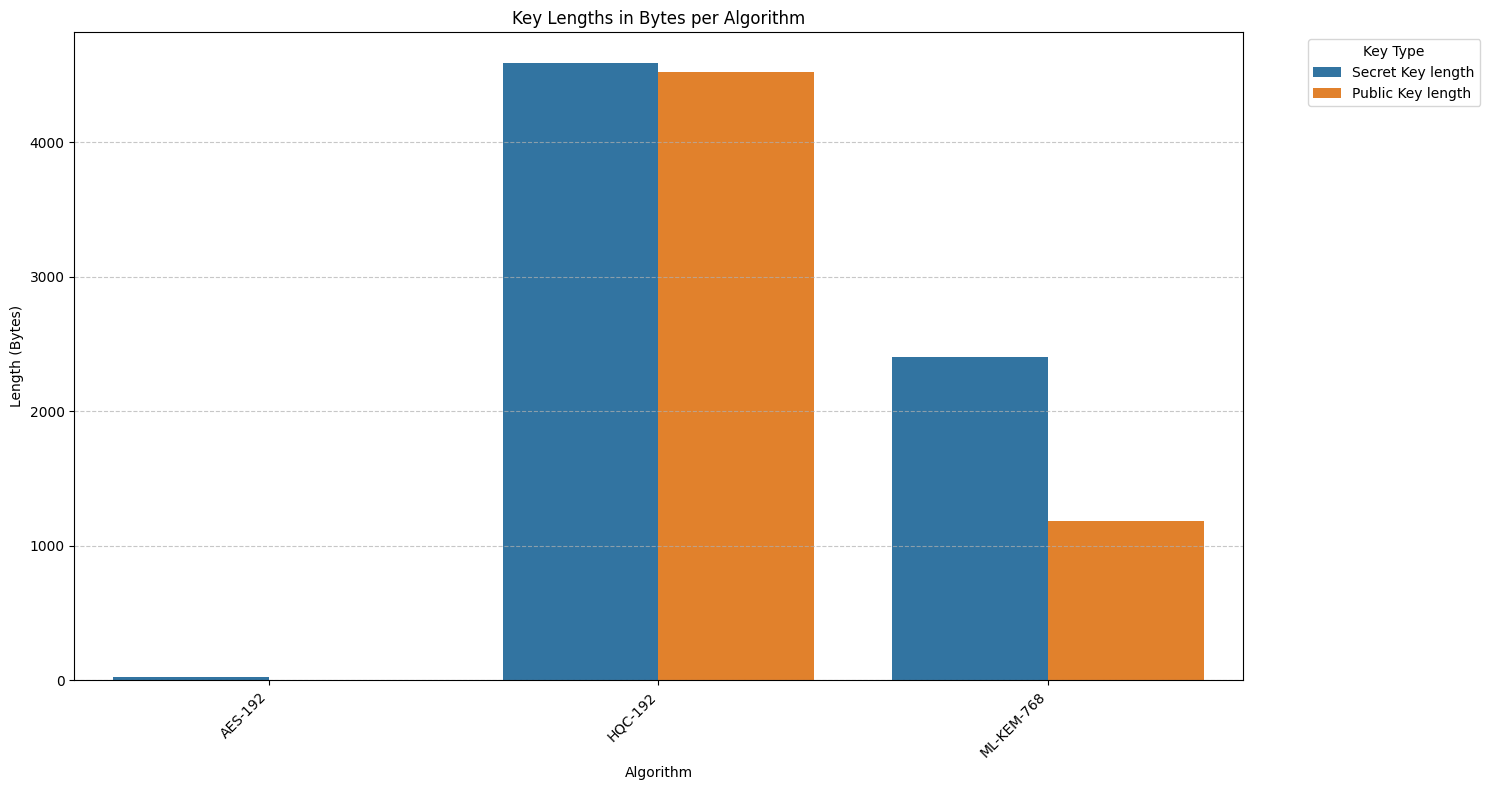

In [18]:
plot_key_length_comparison(df_keys_L3)


--- Plot: Key Generation Times ---


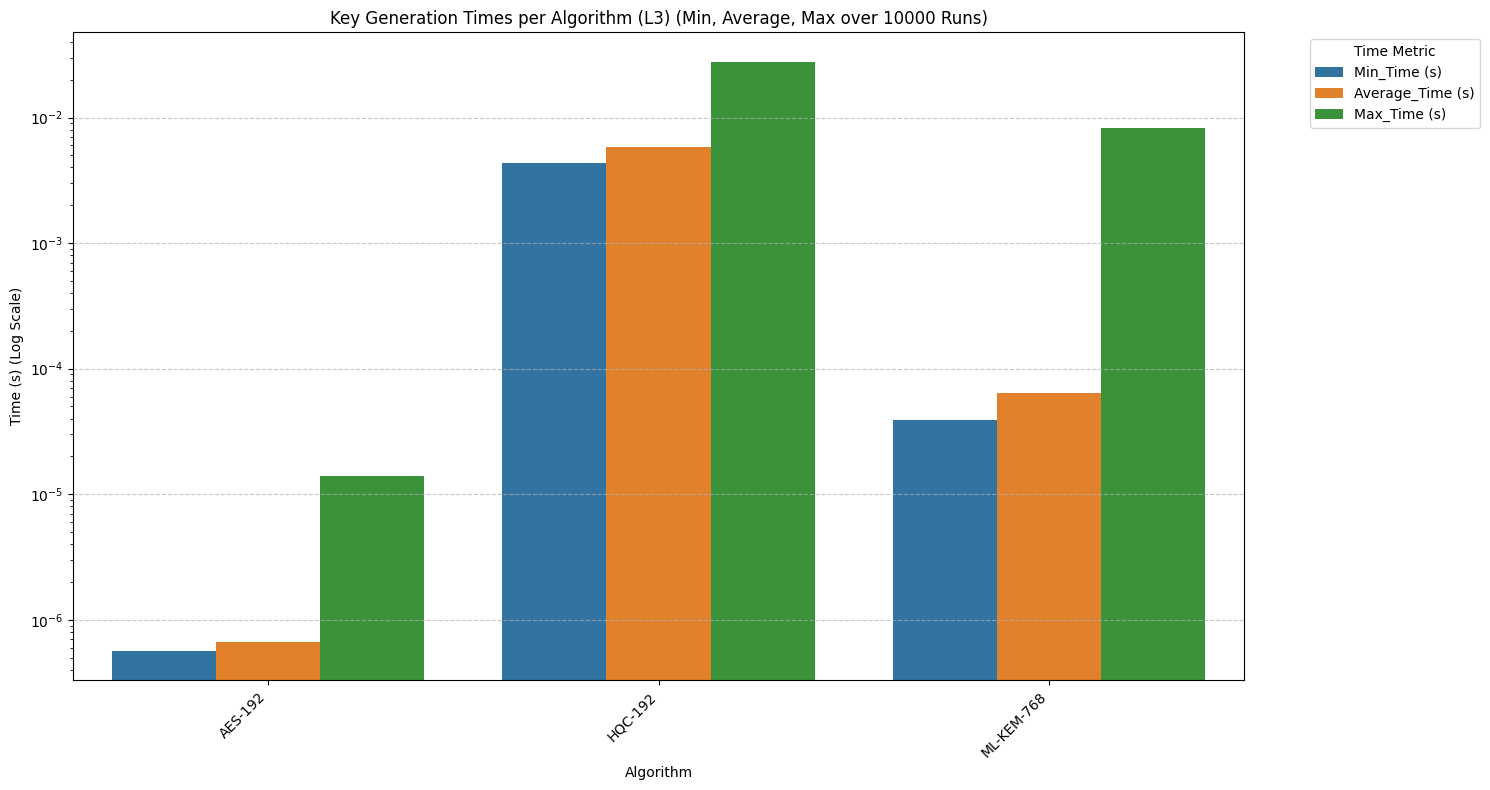

In [19]:
plot_timing_comparison(df_time_keys_L3, test_runs, "Key Generation", 3)


--- Plot: Encryption Times ---


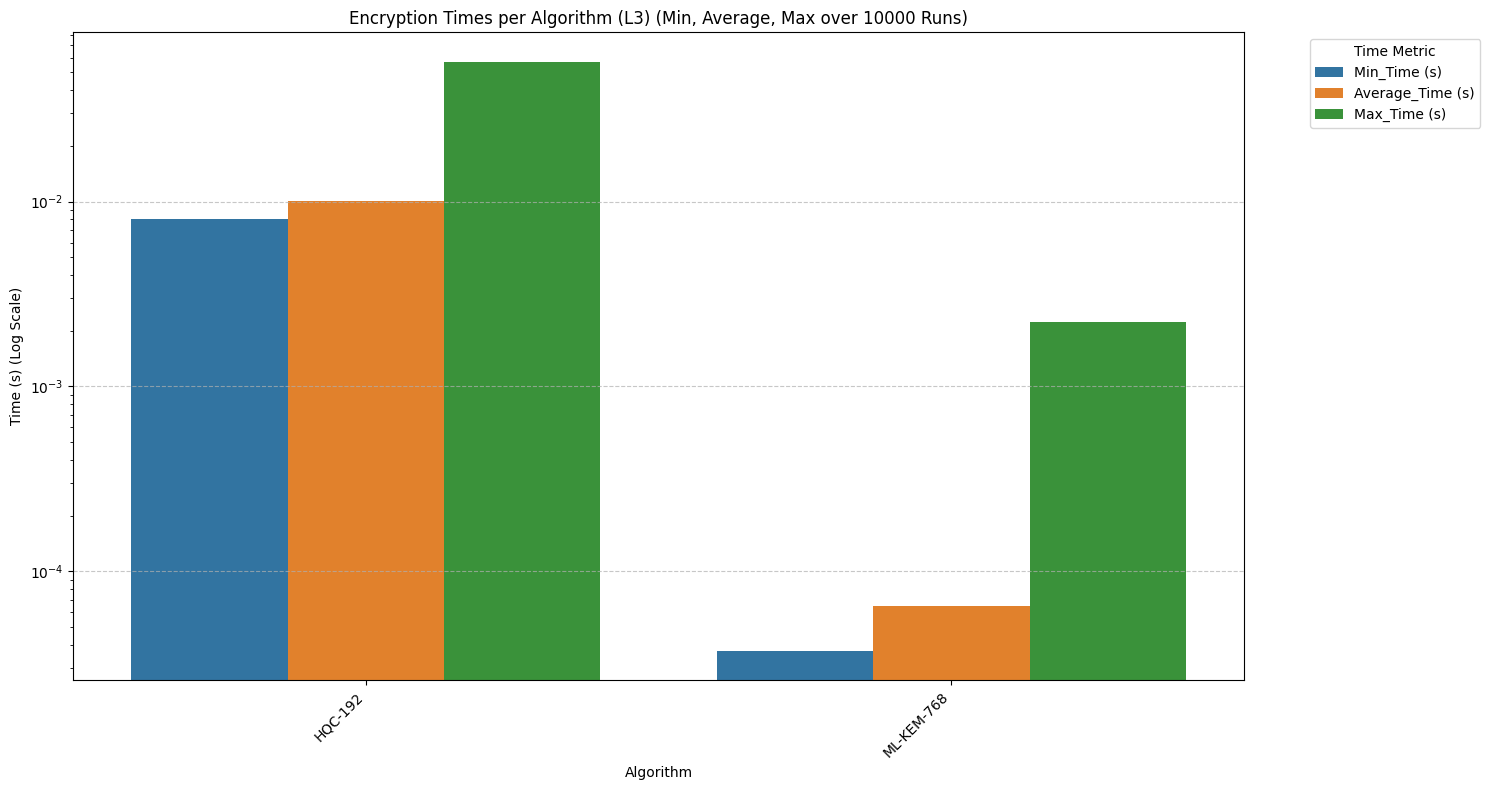

In [20]:
plot_timing_comparison(df_time_encryption_L3, test_runs, "Encryption", 3)


--- Plot: Decryption Times ---


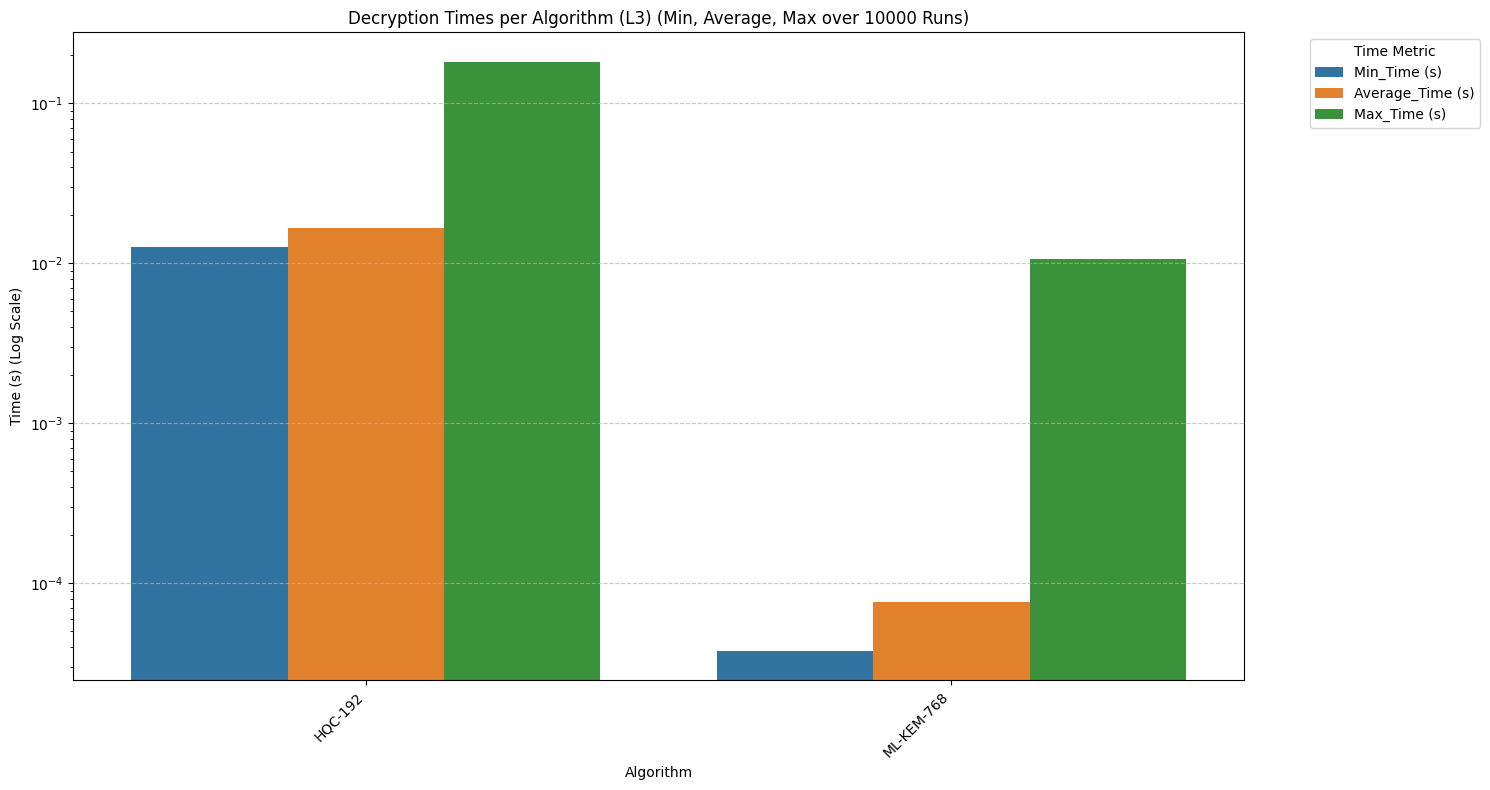

In [21]:
plot_timing_comparison(df_time_decryption_L3, test_runs, "Decryption", 3)

### Level 5 <a id="l5"></a>

In [22]:
print("\nLevel 5...")
df_keys_L5, df_time_keys_L5, df_encryption_L5, df_time_encryption_L5, df_decryption_L5, df_time_decryption_L5 = process_encryption_level(encryption_L5, test_runs, "L5")


Level 5...
Shared Secret for ML-KEM-1024 (L5) matches: True
Shared Secret for HQC-256 (L5) matches: True


In [23]:
display_results("L5", df_keys_L5, "Generated Keys")
display_results("L5", df_time_keys_L5, "Average Key Generation Times")


--- Generated Keys (L5) ---
     Algorithm Security Level  \
0  ML-KEM-1024             L5   
1      HQC-256             L5   
2      AES-256             L5   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [24]:
display_results("L5", df_encryption_L5, "Encryption Data")
display_results("L5", df_time_encryption_L5, "Average Encryption Times")


--- Encryption Data (L5) ---
     Algorithm Security Level  \
0  ML-KEM-1024             L5   
1      HQC-256             L5   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      

In [25]:
display_results("L5", df_decryption_L5, "Decryption Data")
display_results("L5", df_time_decryption_L5, "Average Decryption Times")


--- Decryption Data (L5) ---
     Algorithm Security Level  \
0  ML-KEM-1024             L5   
1      HQC-256             L5   

                                                                                                             Shared Secret Receiver  \
0                                                                  de0eb625f5b0eca78c72e3b7d52f796becec3a427a6af1bae616a39b96984465   
1  ecd820a18423ae5f6496ac905fc7be1e745a2eb40a77271a0ab2a0e020d30b31a3d4fe994a52a666a5e7aff01eaba9034507bbf8a0d1652c8565c0a44dac20bc   

   Shared Secret Receiver length  
0                             32  
1                             64  

--- Average Decryption Times (L5) ---
     Algorithm Security Level   Operation  Min_Time (s)  Average_Time (s)  \
0  ML-KEM-1024             L5  Decryption      0.000056          0.000066   
1      HQC-256             L5  Decryption      0.024582          0.029272   

   Max_Time (s)  
0      0.008982  
1      0.113015  



--- Plot: Key Lengths ---


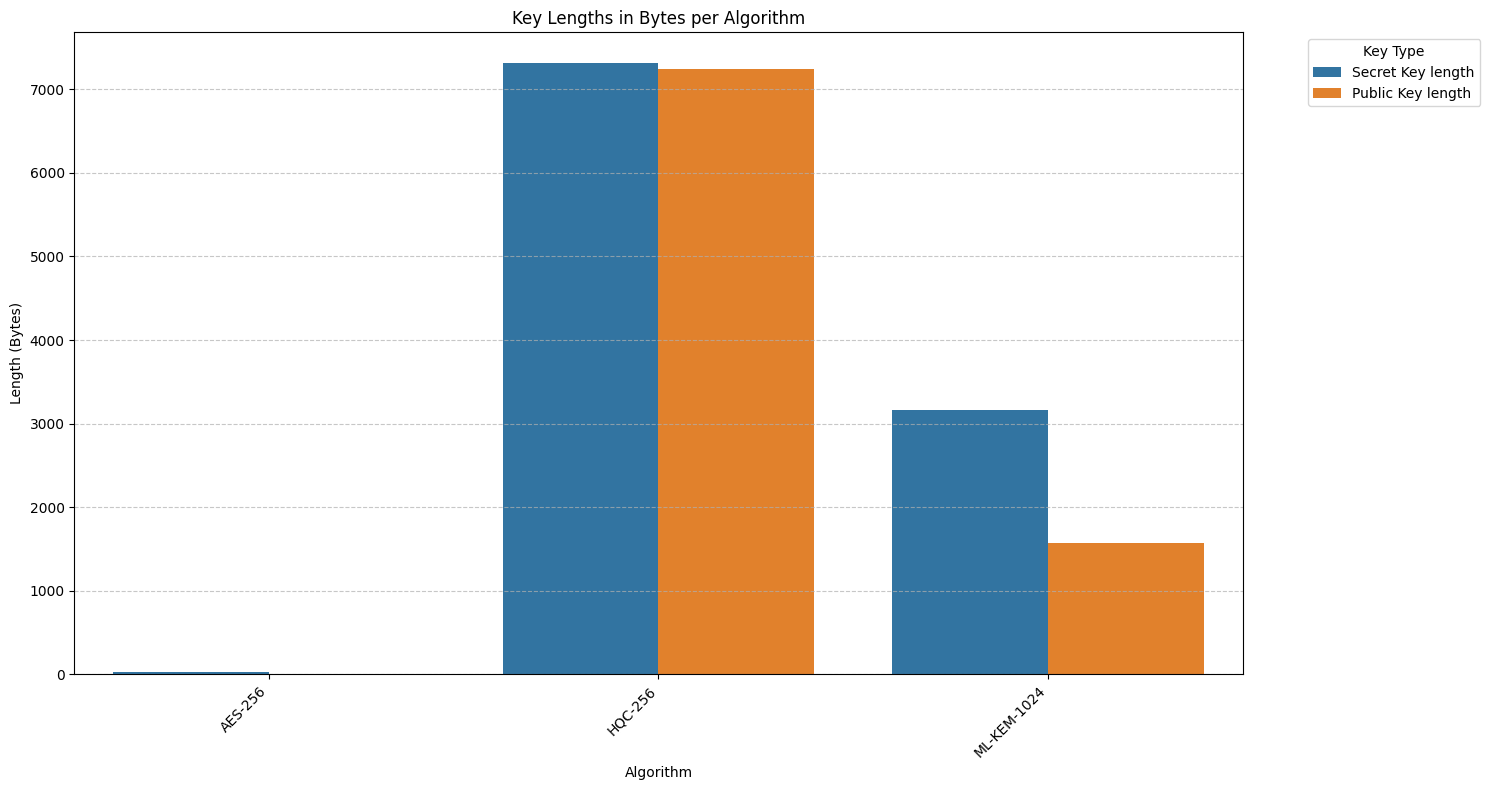

In [26]:
plot_key_length_comparison(df_keys_L5)


--- Plot: Key Generation Times ---


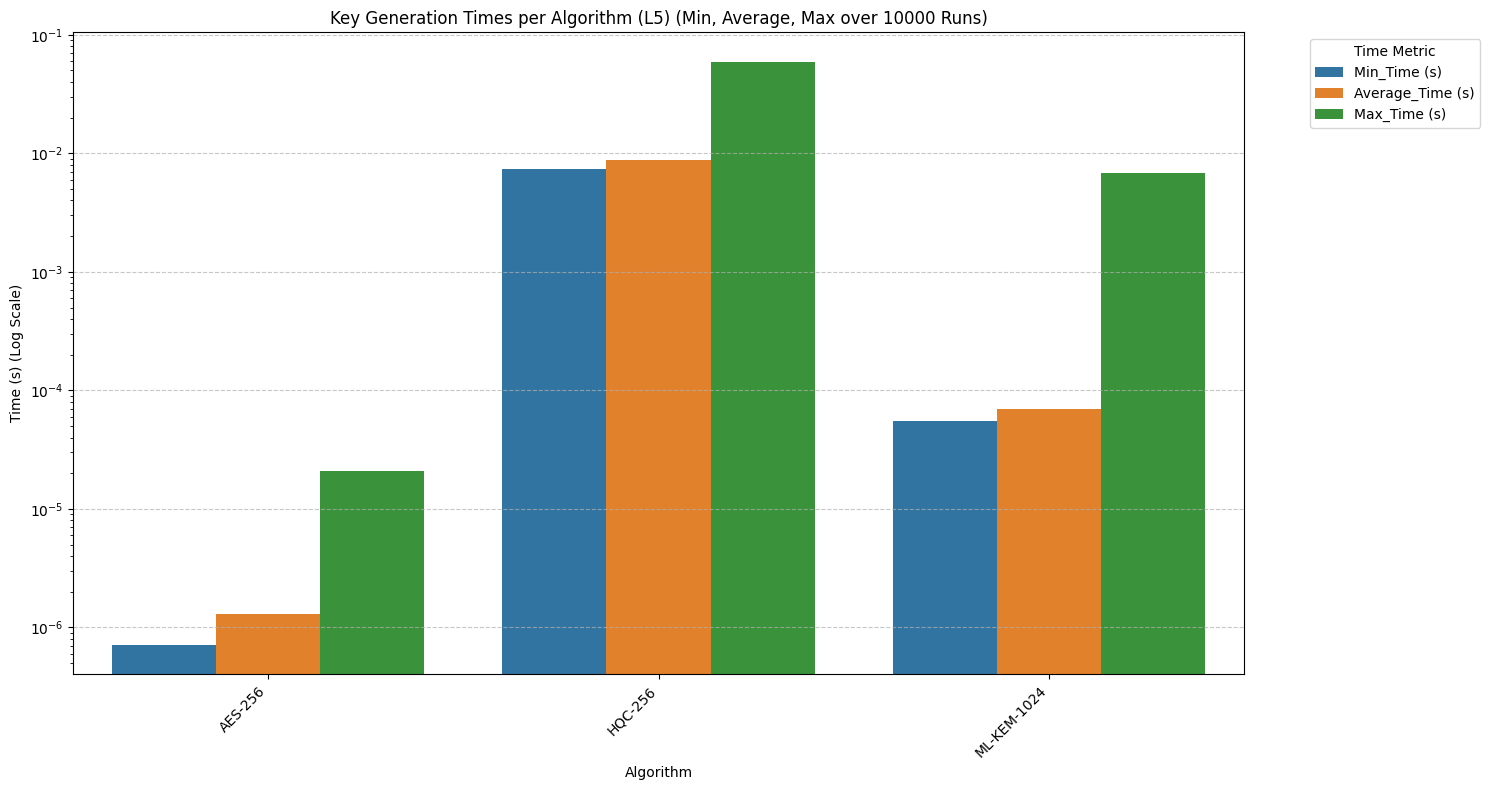

In [27]:
plot_timing_comparison(df_time_keys_L5, test_runs, "Key Generation", 5)


--- Plot: Encryption Times ---


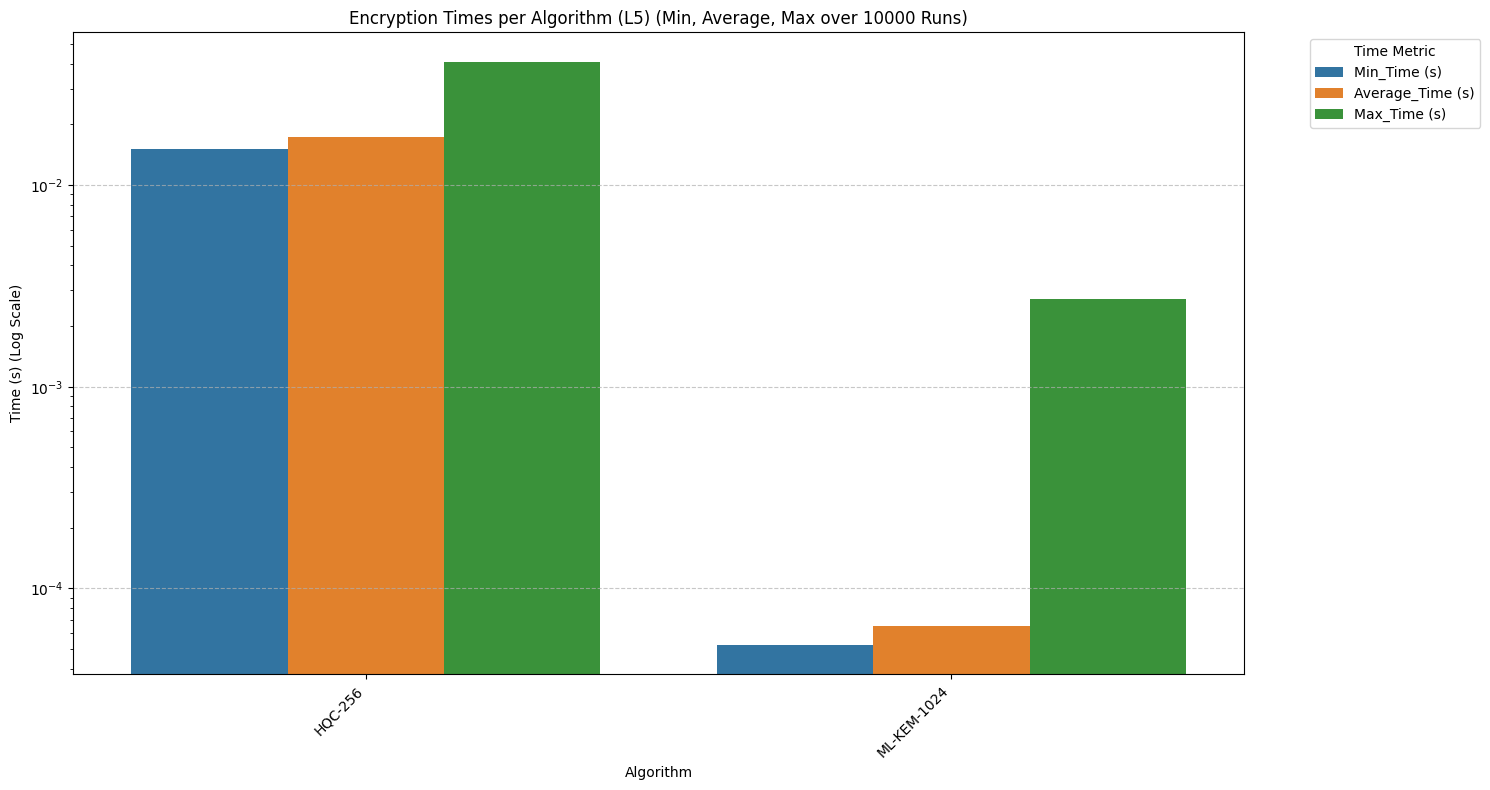

In [28]:
plot_timing_comparison(df_time_encryption_L5, test_runs, "Encryption", 5)


--- Plot: Decryption Times ---


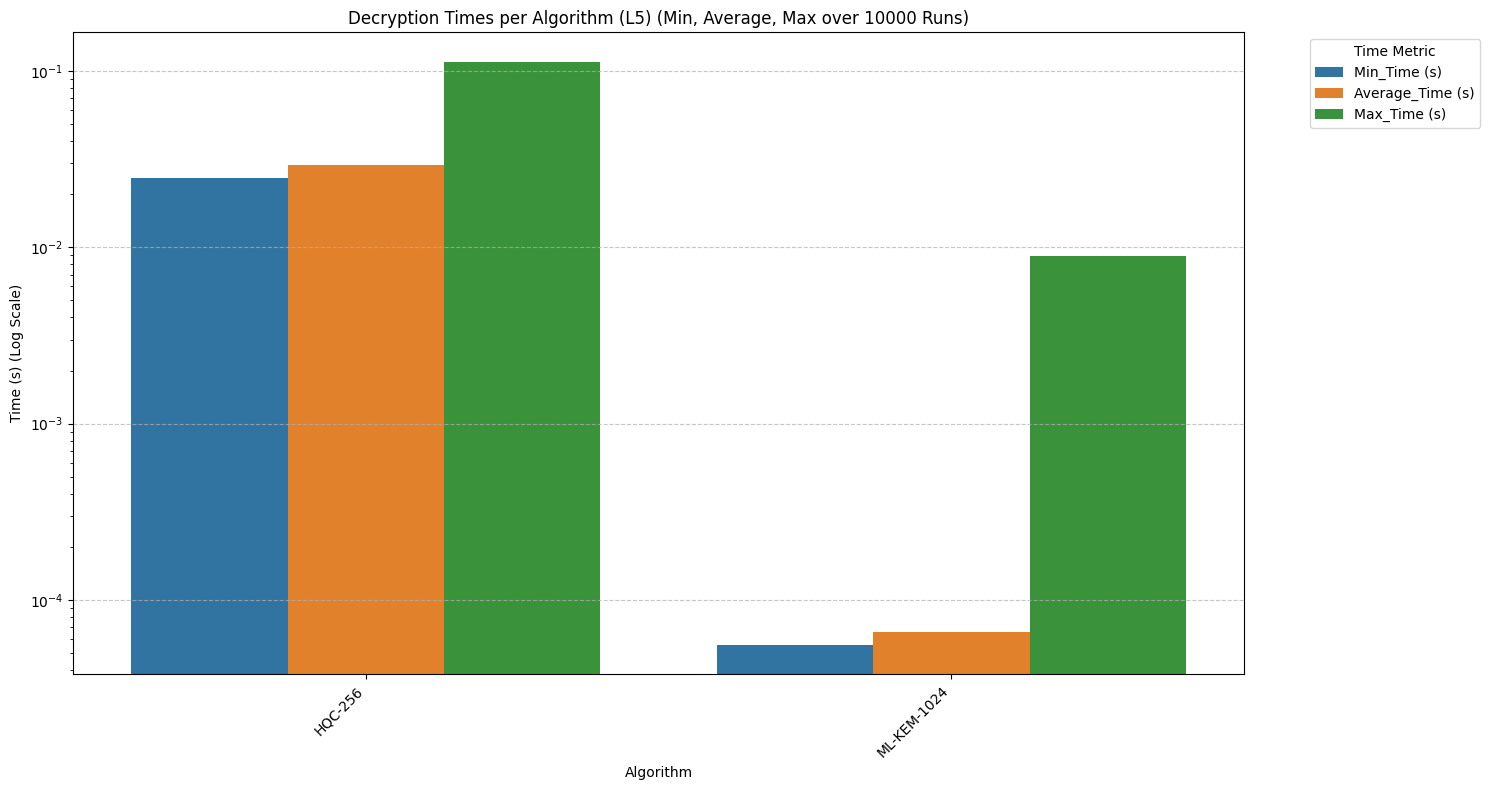

In [29]:
plot_timing_comparison(df_time_decryption_L5, test_runs, "Decryption", 5)

## Conclusion <a id="conclusion"></a>

The performance analysis of selected PQC KEMs reveals **consistent trends** across all NIST Security Levels. **HQC** exhibits larger key lengths and generally longer key generation times, suggesting a higher resource overhead. In contrast, **ML-KEM consistently demonstrates greater efficiency** across key generation, encryption, and decryption operations, positioning it as a more effective and generally better choice in terms of overall performance, despite occasional outliers in its maximum key generation times.